In [ ]:
import os

images_dir = "images"
os.makedirs(images_dir, exist_ok=True)

for file in os.listdir(images_dir):
    print(file)

In [ ]:
import pandas as pd
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
labels_path = 'labels.csv'
if not os.path.exists(labels_path):
    raise FileNotFoundError(f"Could not find {labels_path}. Current working directory: {os.getcwd()}")

labels_df = pd.read_csv(labels_path, sep=',', header=None)
labels_df.columns = ['image_id', 'class', 'x_min', 'y_min', 'x_max', 'y_max']

# Normalize image_id and take first 1000 rows
labels_df['image_id'] = labels_df['image_id'].apply(lambda x: f"{int(x):08d}")
labels_df = labels_df.iloc[:1000]

# Use the existing images_dir if defined, otherwise fallback to 'images'
try:
    images_dir
except NameError:
    images_dir = 'images'

# Ensure a fixed size for all images so numpy can form a single array
target_size = (224, 224)

images = []
for index, row in labels_df.iterrows():
    img_path = os.path.join(images_dir, f"{row['image_id']}.jpg")
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error loading image: {img_path}")
        continue
    # convert grayscale to BGR if needed
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    img = cv2.resize(img, target_size)
    images.append(img)

if len(images) == 0:
    images = np.array(images)
    print("No images loaded. Please check the image paths.")
else:
    images = np.array(images)
    print(f"{len(images)} images loaded successfully. Array shape: {images.shape}")

1000 images loaded successfully. Array shape: (1000, 224, 224, 3)


In [11]:
# Analyze the distribution of vehicle types in the limited dataset
vehicle_types = labels_df['class'].value_counts()
print("Distribution of vehicle types:")
print(vehicle_types)

# Address data quality issues arising from the discrepancy between labels and actual image filenames
# Sorting the image filenames
labels_df = labels_df.sort_values('image_id')

Distribution of vehicle types:
class
car                      682
pickup_truck             111
motorized_vehicle         61
articulated_truck         30
work_van                  29
bus                       28
pedestrian                23
single_unit_truck         18
bicycle                   12
non-motorized_vehicle      5
motorcycle                 1
Name: count, dtype: int64


In [12]:
if len(images)>0:
    processed_images = [cv2.resize(img,(224,224)) for img in images]
    processed_images = np.array(processed_images)
    print("Images resized successfully.")

Images resized successfully.


In [13]:
labels = labels_df['class'].to_numpy()
bounding_boxes = labels_df[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()

unique_labels = np.unique(labels)
label_to_index = {label: index for index, label in enumerate(unique_labels)}
index_to_label = {index: label for label, index in enumerate(unique_labels)}
labels = np.array([label_to_index[label] for label in labels])

In [15]:
X_train, X_test, y_train, y_test, bbox_train, bbox_test = train_test_split(processed_images, labels, bounding_boxes, test_size=0.2, random_state=42)

In [16]:
def create_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    vehicle_class = layers.Dense(num_classes, activation='softmax', name='vehicle_class')(x)
    bounding_box = layers.Dense(4, name='bounding_box')(x)

    model = keras.Model(inputs=inputs, outputs=[vehicle_class, bounding_box])
    return model

input_shape = processed_images[0].shape
num_classes = len(unique_labels)
model = create_model(input_shape, num_classes)


model.compile(optimizer='adam',
              loss={'vehicle_class': 'sparse_categorical_crossentropy', 'bounding_box': 'mse'},
              metrics={'vehicle_class': 'accuracy', 'bounding_box': 'mae'})

model.fit(X_train, {'vehicle_class': y_train, 'bounding_box': bbox_train}, epochs=100, validation_data=(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}))

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 367ms/step - bounding_box_loss: 685910.8125 - bounding_box_mae: 320.1083 - loss: 686455.9375 - vehicle_class_accuracy: 0.0775 - vehicle_class_loss: 544.8463 - val_bounding_box_loss: 25984.9102 - val_bounding_box_mae: 127.6223 - val_loss: 26147.4395 - val_vehicle_class_accuracy: 0.0350 - val_vehicle_class_loss: 337.8738
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step - bounding_box_loss: 23119.0293 - bounding_box_mae: 117.9777 - loss: 23326.0977 - vehicle_class_accuracy: 0.0300 - vehicle_class_loss: 207.0647 - val_bounding_box_loss: 20927.6602 - val_bounding_box_mae: 109.8443 - val_loss: 20746.8359 - val_vehicle_class_accuracy: 0.0750 - val_vehicle_class_loss: 106.1104
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 362ms/step - bounding_box_loss: 20406.3379 - bounding_box_mae: 109.0395 - loss: 20478.2734 - vehicle_class_accuracy: 0.1975 - vehicle_class_loss: 71.9364 - val_bounding_box_loss: 19861.9355 - val_bounding_box_mae: 107.6947 - val_loss

In [17]:
test_results = model.evaluate(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}, verbose=2)
print('\nTest results:', test_results)

7/7 - 0s - 66ms/step - bounding_box_loss: 23853.9668 - bounding_box_mae: 112.8107 - loss: 23431.1270 - vehicle_class_accuracy: 0.6150 - vehicle_class_loss: 8.3666

Test results: [23431.126953125, 8.366601943969727, 23853.966796875, 112.81072998046875, 0.6150000095367432]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


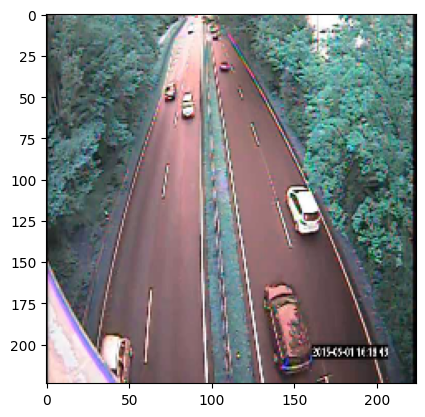

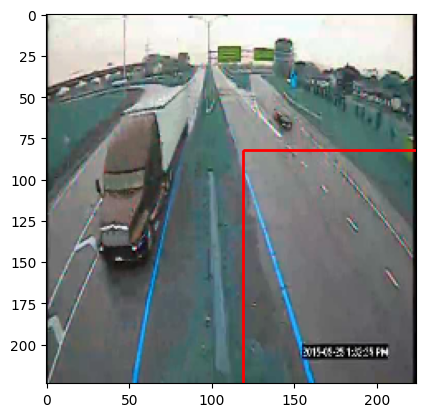

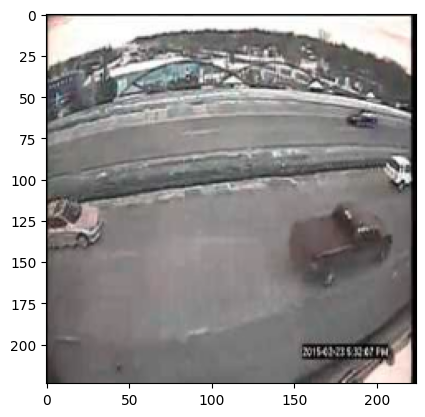

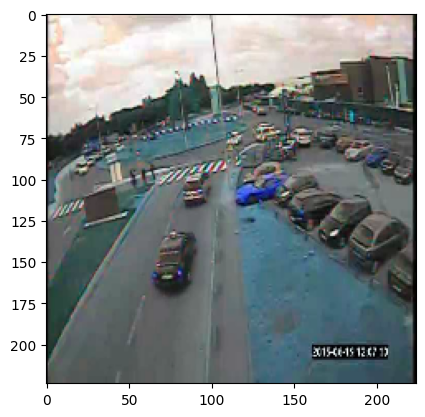

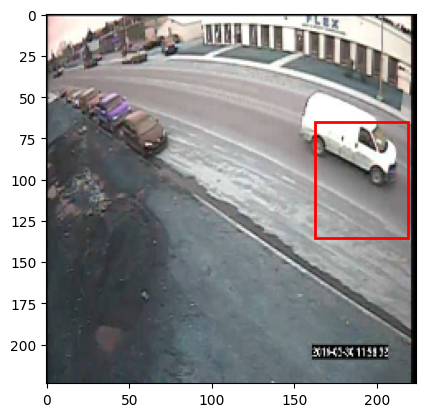

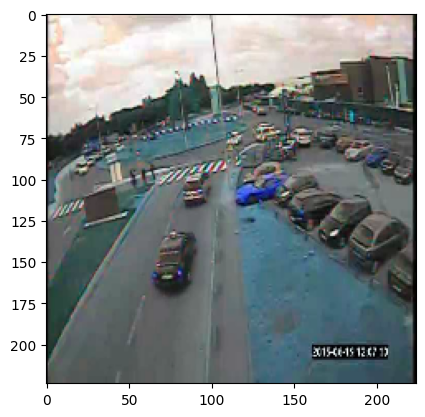

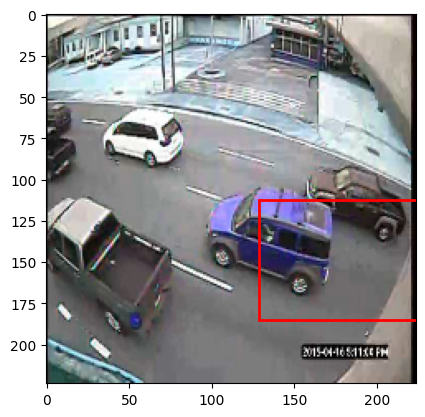

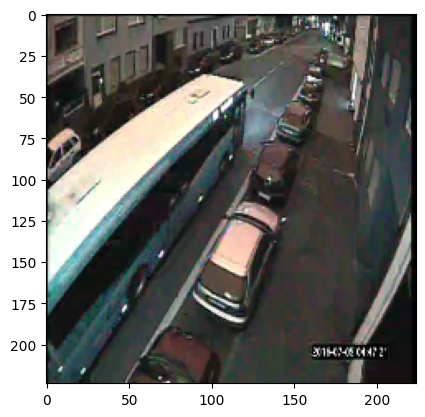

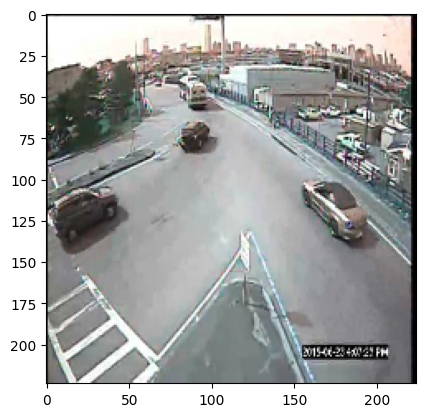

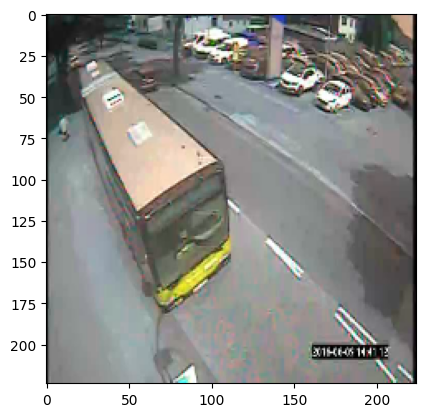

In [ ]:
import matplotlib.pyplot as plt

# Choose a few sample images for inference
sample_images = X_test[:100]  # Adjust the number of sample images as needed

# Perform inference on the sample images
predictions = model.predict(sample_images)

# Extract the predicted bounding box coordinates
predicted_bounding_boxes = predictions[1]

# Visualize the sample images with predicted bounding boxes
for i in range(len(sample_images)):
    plt.figure()
    plt.imshow(sample_images[i])
    plt.gca().add_patch(plt.Rectangle((predicted_bounding_boxes[i][0], predicted_bounding_boxes[i][1]),
                                     predicted_bounding_boxes[i][2] - predicted_bounding_boxes[i][0],
                                     predicted_bounding_boxes[i][3] - predicted_bounding_boxes[i][1], 
                                     fill=False, edgecolor='r', linewidth=2))
    plt.show()